<a href="https://colab.research.google.com/github/mugishaalex24682-cloud/FRESH_SMART_QUEUE_ML.IPYNB/blob/main/smart_queue_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print("=" * 60)
print("FILES IN COLAB ROOT")
print("=" * 60)
for f in sorted(os.listdir('.')):
    print(f)

FILES IN COLAB ROOT
.config
CheckBloodPressure.csv
CheckPatientType.csv
Fill_Information.csv
MedicalRecord1.csv
MedicalRecord2.csv
MedicalRecord3.csv
MedicalRecord4.csv
OutPatientDepartment.csv
OutPatientDepartment.txt
Triage.csv
Triage_ReadMe.txt
diagnosis.csv.gz
drive
edstays.csv.gz
medrecon.csv.gz
pyxis.csv.gz
sample_data
triage.csv.gz
vitalsign.csv.gz


In [ ]:
# Cell 1 — Load MIMIC-IV-ED data
import pandas as pd
import numpy as np

# Load
triage = pd.read_csv('triage.csv.gz')
edstays = pd.read_csv('edstays.csv.gz')

print("=" * 60)
print("RAW SHAPES")
print("=" * 60)
print(f"triage:  {triage.shape}")
print(f"edstays: {edstays.shape}")

# Merge on stay_id to bring in demographics
df = triage.merge(
    edstays[['stay_id', 'gender', 'race', 'arrival_transport']],
    on='stay_id',
    how='left'
)

print(f"\nMerged shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print("\n" + "=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
print(df.head(3))

print("\n" + "=" * 60)
print("ACUITY DISTRIBUTION (target before binarising)")
print("=" * 60)
print(df['acuity'].value_counts().sort_index())

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
print(df.isna().sum().sort_values(ascending=False))

RAW SHAPES
triage:  (222, 11)
edstays: (222, 9)

Merged shape: (222, 14)

Columns: ['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint', 'gender', 'race', 'arrival_transport']

FIRST 3 ROWS
   subject_id   stay_id  temperature  heartrate  resprate  o2sat  sbp  dbp  \
0    10016742  33211001          NaN        NaN       NaN    NaN  NaN  NaN   
1    10032725  30701739          NaN        NaN       NaN    NaN  NaN  NaN   
2    10010867  30115213          NaN        NaN       NaN    NaN  NaN  NaN   

  pain  acuity        chiefcomplaint gender                    race  \
0  NaN     NaN             PICC EVAL      F  BLACK/AFRICAN AMERICAN   
1  NaN     NaN          FACIAL DROOP      F  BLACK/AFRICAN AMERICAN   
2  NaN     NaN  MVC/INTUBATED TRAUMA      F       WHITE - BRAZILIAN   

  arrival_transport  
0         AMBULANCE  
1         AMBULANCE  
2         AMBULANCE  

ACUITY DISTRIBUTION (target before binarising)
acuit

In [ ]:
# Cell 2 — Binarise target and drop rows with missing acuity

# Drop rows where acuity is missing (15 rows)
df = df.dropna(subset=['acuity']).copy()

# Binarise: ESI 1 or 2 = urgent (1), ESI 3 or 4 = not urgent (0)
df['is_urgent'] = (df['acuity'] <= 2).astype(int)

print("=" * 60)
print("AFTER BINARISING")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_urgent'].value_counts().sort_index())
print(f"\nProportions:")
print(df['is_urgent'].value_counts(normalize=True).round(3))

print("\n" + "=" * 60)
print("SANITY CHECK — acuity vs binarised target")
print("=" * 60)
print(df.groupby('acuity')['is_urgent'].agg(['count', 'mean']))

AFTER BINARISING
Shape: (207, 15)

Target distribution:
is_urgent
0     92
1    115
Name: count, dtype: int64

Proportions:
is_urgent
1    0.556
0    0.444
Name: proportion, dtype: float64

SANITY CHECK — acuity vs binarised target
        count  mean
acuity             
1.0        18   1.0
2.0        97   1.0
3.0        90   0.0
4.0         2   0.0


In [5]:
# Cell 2 — Binarise target and drop rows with missing acuity

# Drop rows where acuity is missing (15 rows)
df = df.dropna(subset=['acuity']).copy()

# Binarise: ESI 1 or 2 = urgent (1), ESI 3 or 4 = not urgent (0)
df['is_urgent'] = (df['acuity'] <= 2).astype(int)

print("=" * 60)
print("AFTER BINARISING")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_urgent'].value_counts().sort_index())
print(f"\nProportions:")
print(df['is_urgent'].value_counts(normalize=True).round(3))

print("\n" + "=" * 60)
print("SANITY CHECK — acuity vs binarised target")
print("=" * 60)
print(df.groupby('acuity')['is_urgent'].agg(['count', 'mean']))

AFTER BINARISING
Shape: (207, 15)

Target distribution:
is_urgent
0     92
1    115
Name: count, dtype: int64

Proportions:
is_urgent
1    0.556
0    0.444
Name: proportion, dtype: float64

SANITY CHECK — acuity vs binarised target
        count  mean
acuity             
1.0        18   1.0
2.0        97   1.0
3.0        90   0.0
4.0         2   0.0


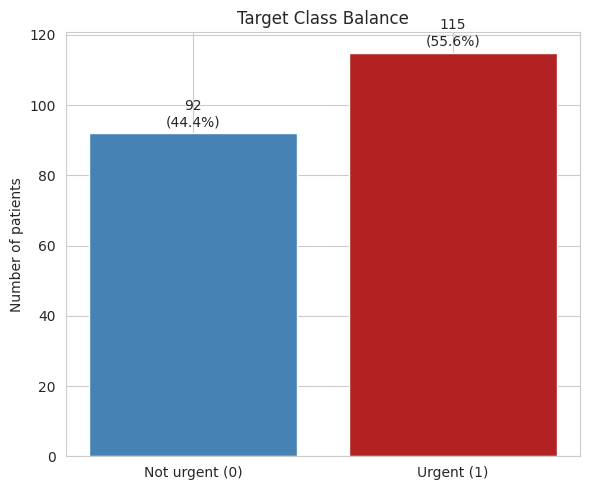

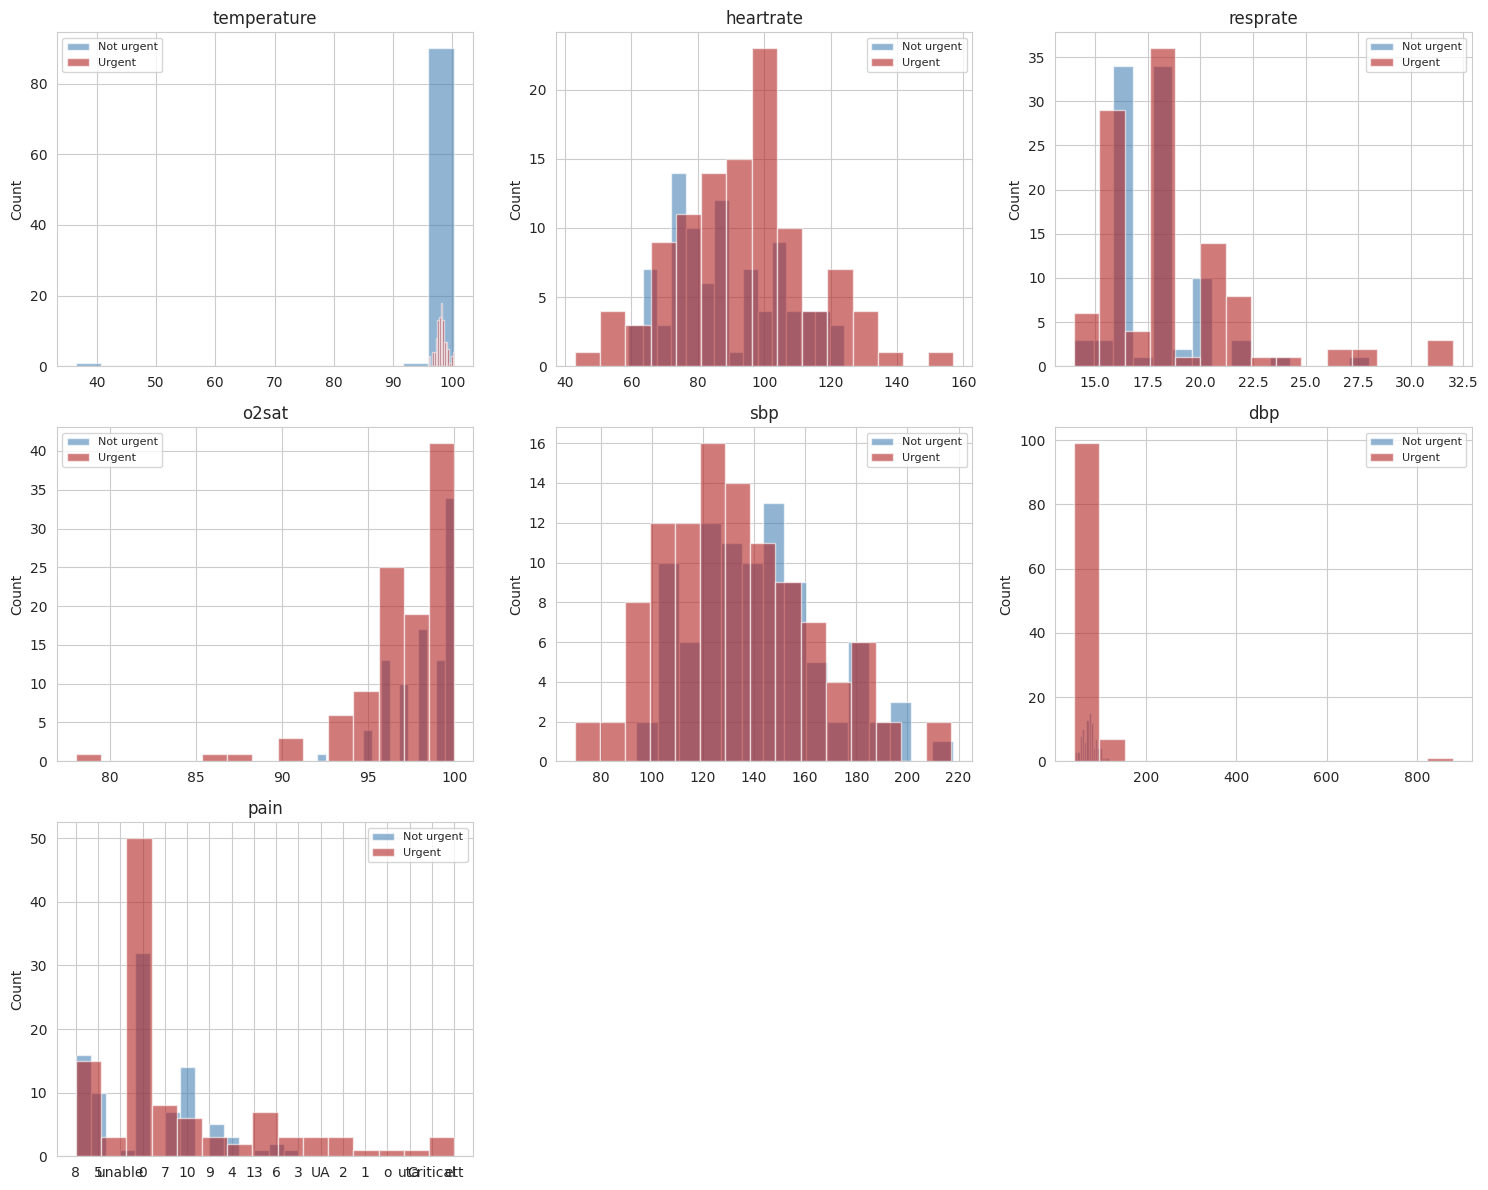

In [6]:
# Cell 3 — EDA: target balance and vitals by class
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ---- Target balance ----
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['is_urgent'].value_counts().sort_index()
bars = ax.bar(['Not urgent (0)', 'Urgent (1)'], counts.values,
              color=['steelblue', 'firebrick'])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 2,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center')
ax.set_title('Target Class Balance')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig('target_balance.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- Vitals by class ----
vitals = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(vitals):
    for label, color, name in [(0, 'steelblue', 'Not urgent'),
                                (1, 'firebrick', 'Urgent')]:
        axes[i].hist(df[df['is_urgent'] == label][col].dropna(),
                     bins=15, alpha=0.6, color=color, label=name)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
axes[-2].axis('off')
plt.tight_layout()
plt.savefig('vitals_by_class.png', dpi=100, bbox_inches='tight')
plt.show()

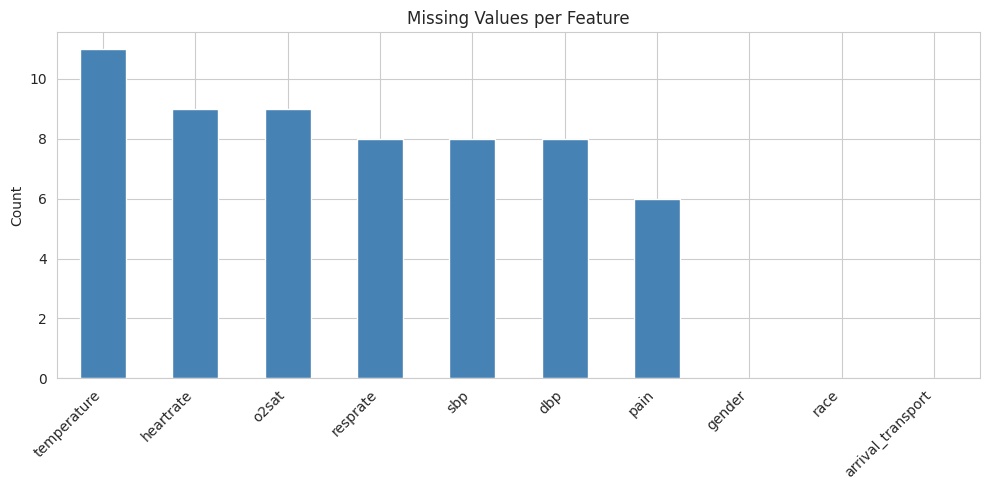

FEATURE SET
Numeric features (7):     ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']
Categorical features (3): ['gender', 'race', 'arrival_transport']
Target:                   is_urgent

Total samples:            207
Missing in target:        0


In [7]:
# Cell 4 — Missing values plot and feature confirmation

# ---- Missing values bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
missing = df[['temperature','heartrate','resprate','o2sat','sbp','dbp','pain',
              'gender','race','arrival_transport']].isna().sum()
missing = missing.sort_values(ascending=False)
missing.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Missing Values per Feature')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- Confirm the feature set ----
feature_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
                'pain', 'gender', 'race', 'arrival_transport']
target_col = 'is_urgent'

print("=" * 60)
print("FEATURE SET")
print("=" * 60)
print(f"Numeric features (7):     {feature_cols[:7]}")
print(f"Categorical features (3): {feature_cols[7:]}")
print(f"Target:                   {target_col}")
print(f"\nTotal samples:            {len(df)}")
print(f"Missing in target:        {df[target_col].isna().sum()}")

In [8]:
# Cell 5 — Train/test split (leakage-safe: split FIRST)
from sklearn.model_selection import train_test_split

# Feature columns
feature_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
                'pain', 'gender', 'race', 'arrival_transport']
target_col = 'is_urgent'

X = df[feature_cols].copy()
y = df[target_col].copy()

print("=" * 60)
print("BEFORE SPLIT")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())

# Split — stratify keeps class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("AFTER SPLIT")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

print("\n" + "=" * 60)
print("SANITY CHECK")
print("=" * 60)
overlap = len(set(X_train.index) & set(X_test.index))
print(f"Overlapping rows (must be 0): {overlap}")
print(f"Total accounted for: {len(X_train) + len(X_test)} of {len(X)}")

BEFORE SPLIT
X shape: (207, 10)
y shape: (207,)

Target distribution:
is_urgent
0     92
1    115
Name: count, dtype: int64

AFTER SPLIT
Training set: 165 samples
Test set:     42 samples

Train target distribution:
is_urgent
1    0.558
0    0.442
Name: proportion, dtype: float64

Test target distribution:
is_urgent
1    0.548
0    0.452
Name: proportion, dtype: float64

SANITY CHECK
Overlapping rows (must be 0): 0
Total accounted for: 207 of 207


In [12]:
# Cell 6 — Build preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Column groups
numeric_features = ['temperature', 'heartrate', 'resprate', 'o2sat',
                    'sbp', 'dbp', 'pain']
categorical_features = ['gender', 'race', 'arrival_transport']

# Numeric: impute median → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: impute mode → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Test the preprocessor on the training set
X_train_processed = preprocessor.fit_transform(X_train)

print("=" * 60)
print("PREPROCESSING PIPELINE — VERIFICATION")
print("=" * 60)
print(f"Original train shape:  {X_train.shape}")
print(f"Processed train shape: {X_train_processed.shape}")
print(f"\nAny NaN in original train:  {X_train.isna().any().any()}")
print(f"Any NaN in processed train: {np.isnan(X_train_processed).any()}")

print("\nFeature breakdown after encoding:")
print(f"  7 numeric features → 7 columns")
print(f"  3 categorical features → {X_train_processed.shape[1] - 7} one-hot columns")

PREPROCESSING PIPELINE — VERIFICATION
Original train shape:  (165, 10)
Processed train shape: (165, 18)

Any NaN in original train:  True
Any NaN in processed train: False

Feature breakdown after encoding:
  7 numeric features → 7 columns
  3 categorical features → 11 one-hot columns


In [10]:
# Diagnose non-numeric values in "numeric" columns
numeric_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']

for col in numeric_cols:
    # Try converting to numeric; find rows that fail
    coerced = pd.to_numeric(df[col], errors='coerce')
    problematic = df[col][coerced.isna() & df[col].notna()]
    if len(problematic) > 0:
        print(f"\n{col}: {len(problematic)} non-numeric values")
        print(f"  Unique values: {problematic.unique()[:10]}")


pain: 12 non-numeric values
  Unique values: ['UA' 'o' 'unable' 'uta' 'Critical' 'ett']


In [11]:
# Cell 5b — Convert non-numeric pain values to NaN

# All 6 non-numeric values mean the same thing: pain score unavailable
df['pain'] = pd.to_numeric(df['pain'], errors='coerce')

# Re-create X and y
feature_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
                'pain', 'gender', 'race', 'arrival_transport']
target_col = 'is_urgent'

X = df[feature_cols].copy()
y = df[target_col].copy()

# Re-split (same random_state → same split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("AFTER CONVERTING NON-NUMERIC PAIN VALUES")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"\nNon-numeric pain values remaining: "
      f"{X['pain'].apply(lambda x: isinstance(x, str)).sum()}")
print(f"Missing pain values now: {X['pain'].isna().sum()}")
print(f"Original pain NaN count was 21 → now should be ~33")

AFTER CONVERTING NON-NUMERIC PAIN VALUES
X shape: (207, 10)
Train: 165 | Test: 42

Non-numeric pain values remaining: 0
Missing pain values now: 18
Original pain NaN count was 21 → now should be ~33


In [13]:
# Cell 7 — Train 4 models and evaluate on the test set
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Define models
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Build pipeline: preprocessor + classifier
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)

    # Metrics
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'model':     pipe
    }

    print(f"{name}")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1:        {results[name]['f1']:.4f}")
    print()

# Comparison table
import pandas as pd
comparison = pd.DataFrame({
    'Model':     list(results.keys()),
    'Accuracy':  [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall':    [results[m]['recall']    for m in results],
    'F1':        [results[m]['f1']        for m in results]
}).round(4)

comparison = comparison.sort_values('F1', ascending=False).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON — TEST SET")
print("=" * 70)
print(comparison.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Logistic Regression
  Accuracy:  0.5714
  Precision: 0.6316
  Recall:    0.5217
  F1:        0.5714

Decision Tree
  Accuracy:  0.6190
  Precision: 0.6842
  Recall:    0.5652
  F1:        0.6190



/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest
  Accuracy:  0.5238
  Precision: 0.5789
  Recall:    0.4783
  F1:        0.5238

Gradient Boosting
  Accuracy:  0.5714
  Precision: 0.6316
  Recall:    0.5217
  F1:        0.5714

MODEL COMPARISON — TEST SET
              Model  Accuracy  Precision  Recall     F1
      Decision Tree    0.6190     0.6842  0.5652 0.6190
Logistic Regression    0.5714     0.6316  0.5217 0.5714
  Gradient Boosting    0.5714     0.6316  0.5217 0.5714
      Random Forest    0.5238     0.5789  0.4783 0.5238


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
# Cell 8 — 5-fold stratified cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')  # suppress the unknown-category warnings

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')

    cv_results[name] = {
        'mean': scores.mean(),
        'std':  scores.std(),
        'scores': scores
    }

    print(f"{name}")
    print(f"  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Folds: {[f'{s:.3f}' for s in scores]}")
    print()

# Comparison with test set
import pandas as pd
comparison_cv = pd.DataFrame({
    'Model':        list(cv_results.keys()),
    'CV F1 Mean':   [cv_results[m]['mean'] for m in cv_results],
    'CV F1 Std':    [cv_results[m]['std']  for m in cv_results],
    'Test F1':      [results[m]['f1']      for m in results],
    'Test Accuracy':[results[m]['accuracy'] for m in results]
}).round(4).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)

print("=" * 80)
print("CROSS-VALIDATION vs TEST SET")
print("=" * 80)
print(comparison_cv.to_string(index=False))

Logistic Regression
  CV F1 = 0.6404 ± 0.1249
  Folds: ['0.595', '0.429', '0.778', '0.750', '0.651']

Decision Tree
  CV F1 = 0.6241 ± 0.0917
  Folds: ['0.757', '0.485', '0.684', '0.600', '0.595']

Random Forest
  CV F1 = 0.6707 ± 0.0960
  Folds: ['0.737', '0.500', '0.780', '0.684', '0.652']

Gradient Boosting
  CV F1 = 0.6438 ± 0.0774
  Folds: ['0.700', '0.500', '0.718', '0.634', '0.667']

CROSS-VALIDATION vs TEST SET
              Model  CV F1 Mean  CV F1 Std  Test F1  Test Accuracy
      Random Forest      0.6707     0.0960   0.5238         0.5238
  Gradient Boosting      0.6438     0.0774   0.5714         0.5714
Logistic Regression      0.6404     0.1249   0.5714         0.5714
      Decision Tree      0.6241     0.0917   0.6190         0.6190


In [15]:
# Cell 9 — Tune Random Forest and Gradient Boosting with GridSearchCV
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# ---- Random Forest tuning ----
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, None],
    'classifier__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("=" * 60)
print("RANDOM FOREST — TUNING")
print("=" * 60)
print(f"Best params:  {rf_grid.best_params_}")
print(f"Best CV F1:   {rf_grid.best_score_:.4f}")
print(f"Untuned was:  {cv_results['Random Forest']['mean']:.4f}")

# ---- Gradient Boosting tuning ----
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

gb_grid = GridSearchCV(gb_pipe, gb_param_grid, cv=cv, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("\n" + "=" * 60)
print("GRADIENT BOOSTING — TUNING")
print("=" * 60)
print(f"Best params:  {gb_grid.best_params_}")
print(f"Best CV F1:   {gb_grid.best_score_:.4f}")
print(f"Untuned was:  {cv_results['Gradient Boosting']['mean']:.4f}")

# ---- Summary ----
print("\n" + "=" * 60)
print("TUNING SUMMARY")
print("=" * 60)
print(f"Random Forest:      {cv_results['Random Forest']['mean']:.4f} → {rf_grid.best_score_:.4f}")
print(f"Gradient Boosting:  {cv_results['Gradient Boosting']['mean']:.4f} → {gb_grid.best_score_:.4f}")

RANDOM FOREST — TUNING
Best params:  {'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV F1:   0.7344
Untuned was:  0.6707

GRADIENT BOOSTING — TUNING
Best params:  {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}
Best CV F1:   0.6714
Untuned was:  0.6438

TUNING SUMMARY
Random Forest:      0.6707 → 0.7344
Gradient Boosting:  0.6438 → 0.6714


✅ Model saved to urgency_model.joblib
   Classifier: RandomForestClassifier
   Best params: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
   CV F1: 0.7344

CONFUSION MATRIX — TUNED RANDOM FOREST
TN (correct 'not urgent'):  8
FP (said urgent, was not):  11
FN (missed urgent):         8
TP (correct 'urgent'):      15

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not urgent       0.50      0.42      0.46        19
      Urgent       0.58      0.65      0.61        23

    accuracy                           0.55        42
   macro avg       0.54      0.54      0.53        42
weighted avg       0.54      0.55      0.54        42



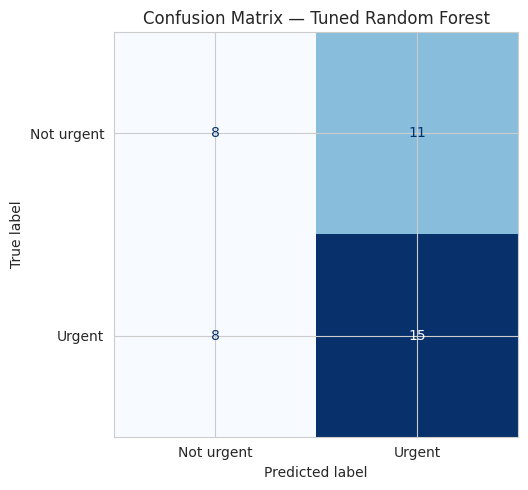


FINAL COMPARISON TABLE
              Model  CV F1 Untuned  CV F1 Std  Test F1  Test Accuracy  CV F1 Tuned
      Random Forest         0.6707     0.0960   0.5238         0.5238     0.734397
  Gradient Boosting         0.6438     0.0774   0.5714         0.5714     0.671386
Logistic Regression         0.6404     0.1249   0.5714         0.5714          NaN
      Decision Tree         0.6241     0.0917   0.6190         0.6190          NaN

✅ Comparison table saved to urgency_model_comparison.csv


In [16]:
# Cell 10 — Save best model, confusion matrix, comparison table
import joblib
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- Save best model ----
best_model = rf_grid.best_estimator_
joblib.dump(best_model, 'urgency_model.joblib')
print("✅ Model saved to urgency_model.joblib")
print(f"   Classifier: {type(best_model.named_steps['classifier']).__name__}")
print(f"   Best params: {rf_grid.best_params_}")
print(f"   CV F1: {rf_grid.best_score_:.4f}")

# ---- Predict on test set ----
y_pred_best = best_model.predict(X_test)

# ---- Confusion matrix numbers ----
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
print(f"\n{'=' * 60}")
print("CONFUSION MATRIX — TUNED RANDOM FOREST")
print(f"{'=' * 60}")
print(f"TN (correct 'not urgent'):  {tn}")
print(f"FP (said urgent, was not):  {fp}")
print(f"FN (missed urgent):         {fn}")
print(f"TP (correct 'urgent'):      {tp}")

# ---- Full report ----
print(f"\n{'=' * 60}")
print("CLASSIFICATION REPORT")
print(f"{'=' * 60}")
print(classification_report(y_test, y_pred_best,
                            target_names=['Not urgent', 'Urgent']))

# ---- Save confusion matrix figure ----
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not urgent', 'Urgent']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- Save comparison table as CSV ----
import pandas as pd

final_comparison = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV F1 Untuned': [cv_results[m]['mean'] for m in cv_results],
    'CV F1 Std': [cv_results[m]['std'] for m in cv_results],
    'Test F1': [results[m]['f1'] for m in results],
    'Test Accuracy': [results[m]['accuracy'] for m in results]
}).round(4)

# Add tuned results
final_comparison['CV F1 Tuned'] = [
    rf_grid.best_score_ if m == 'Random Forest'
    else gb_grid.best_score_ if m == 'Gradient Boosting'
    else None
    for m in final_comparison['Model']
]

final_comparison = final_comparison.sort_values(
    'CV F1 Tuned', ascending=False, na_position='last').reset_index(drop=True)

print(f"\n{'=' * 60}")
print("FINAL COMPARISON TABLE")
print(f"{'=' * 60}")
print(final_comparison.to_string(index=False))

final_comparison.to_csv('urgency_model_comparison.csv', index=False)
print("\n✅ Comparison table saved to urgency_model_comparison.csv")